ASMI
IMI
NORM


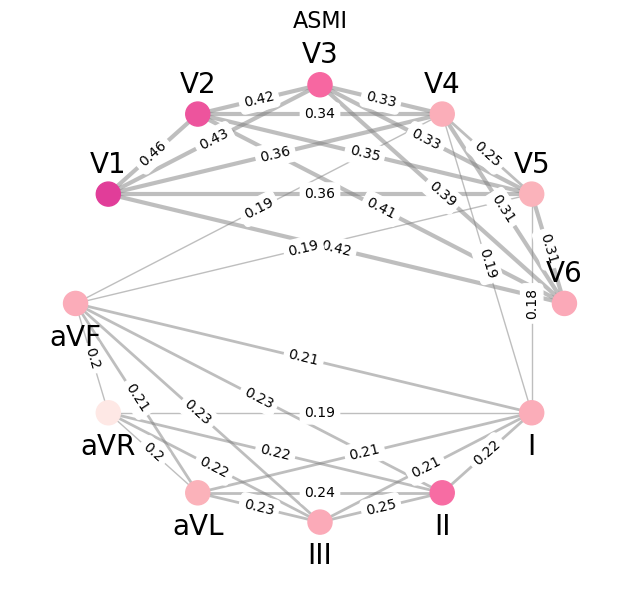

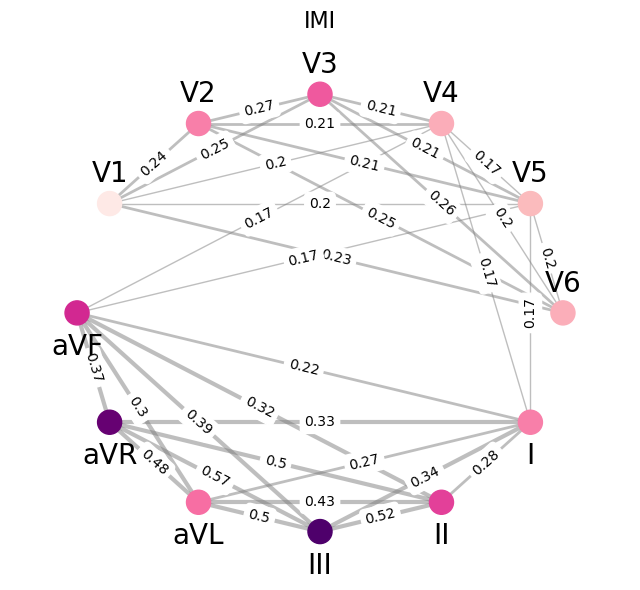

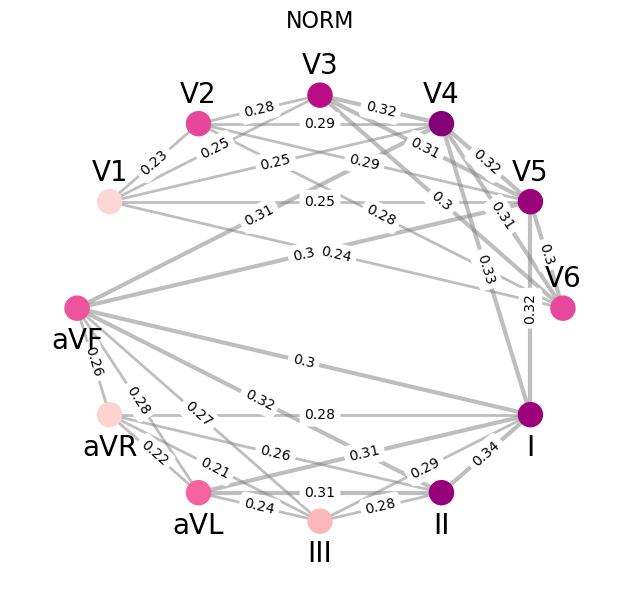

In [2]:
# MI Classification Results and Explainability Analysis

# This notebook loads the saved experiment results and explanation outputs
# to reproduce the plots used in the analysis.

# It visualizes:
# - model performance metrics
# - node and edge importance scores
# - ECG lead relevance patterns

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import networkx as nx
import matplotlib.pyplot as plt
import os

save_root = os.environ.get('SAVE_LOCATION', '.')
save_dir = os.path.join(save_root, 'MI_res/test_results')

# helper code
def change_pos(pos, a, b):
    tmp = pos[a]
    pos[a] = pos[b]
    pos[b] = tmp
    return pos

def get_time_vs_spatial_importance(df, class_to_analyse):
    val = df.loc[ (df['disease'] == class_to_analyse) ] 
    return float(val["spatial_percentage"])
    
def get_edge_importance(df, a,b, class_to_analyse):
    val = df.loc[ (df['disease'] == class_to_analyse) &
                  (df['lead_1'] == a) & 
                  (df['lead_2'] == b)]["mean_importance_score"]
    return np.round(np.double(val),2)

edge_importance_df = pd.read_csv(os.path.join(save_dir,"mean_edge_importance_node_names.csv"));

# which classes?
classes = ["ASMI", "IMI", "NORM"]

for class_of_interest in classes:
    
    print(class_of_interest)
    importance_df = pd.read_csv(os.path.join(save_dir,"node_importance_scores_tp_mi_disease.csv"), index_col=0)
    
    leads = {
        "Lead I": list(range(0, 25)),
        "Lead II": list(range(25, 50)),
        "Lead III": list(range(50, 75)),
        "Lead aVR": list(range(75, 100)),
        "Lead aVL": list(range(100, 125)),
        "Lead aVF": list(range(125, 150)),
        "Lead V1": list(range(150, 175)),
        "Lead V2": list(range(175, 200)),
        "Lead V3": list(range(200, 225)),
        "Lead V4": list(range(225, 250)),
        "Lead V5": list(range(250, 275)),
        "Lead V6": list(range(275, 300)),
    }
    
    values = {
        "Lead I": [],
        "Lead II":  [],
        "Lead III":  [],
        "Lead aVR":  [],
        "Lead aVL":  [],
        "Lead aVF":  [],
        "Lead V1":  [],
        "Lead V2":  [],
        "Lead V3":  [],
        "Lead V4":  [],
        "Lead V5":  [],
        "Lead V6":  [],
    }
    
    importance_df = importance_df.reset_index()  
    
    for index, row in importance_df.iterrows():
        if str(row['Diagnosis'][:]) == class_of_interest:
            values["Lead I"].append(row[leads["Lead I"]].to_numpy()[1:] )
            values["Lead II"].append(row[leads["Lead II"]].to_numpy()[1:] )
            values["Lead III"].append(row[leads["Lead III"]].to_numpy()[1:] )
            values["Lead aVR"].append(row[leads["Lead aVR"]].to_numpy()[1:] )
            values["Lead aVL"].append(row[leads["Lead aVL"]].to_numpy()[1:] )
            values["Lead aVF"].append(row[leads["Lead aVF"]].to_numpy()[1:] )
            values["Lead V1"].append(row[leads["Lead V1"]].to_numpy()[1:] )
            values["Lead V2"].append(row[leads["Lead V2"]].to_numpy()[1:] )
            values["Lead V3"].append(row[leads["Lead V3"]].to_numpy()[1:] )
            values["Lead V4"].append(row[leads["Lead V4"]].to_numpy()[1:] )
            values["Lead V5"].append(row[leads["Lead V5"]].to_numpy()[1:] )
            values["Lead V6"].append(row[leads["Lead V6"]].to_numpy()[1:] )
    
    raw_values = {
        "Lead I": [],
        "Lead II":  [],
        "Lead III":  [],
        "Lead aVR":  [],
        "Lead aVL":  [],
        "Lead aVF":  [],
        "Lead V1":  [],
        "Lead V2":  [],
        "Lead V3":  [],
        "Lead V4":  [],
        "Lead V5":  [],
        "Lead V6":  [],
    }
    for key, value in raw_values.items():
        raw_values[key] = np.mean(values[key])

    # construct graph    
    G = nx.null_graph()
    G.add_edge("V1", "V2", weight = get_edge_importance(edge_importance_df, "V1","V2", class_of_interest))
    G.add_edge("V1", "V3", weight = get_edge_importance(edge_importance_df, "V1","V3", class_of_interest))
    G.add_edge("V1", "V4", weight = get_edge_importance(edge_importance_df, "V1","V4", class_of_interest))
    G.add_edge("V1", "V5", weight = get_edge_importance(edge_importance_df, "V1","V5", class_of_interest))
    G.add_edge("V1", "V6", weight = get_edge_importance(edge_importance_df, "V1","V6", class_of_interest))
    G.add_edge("V2", "V3", weight = get_edge_importance(edge_importance_df, "V2","V3", class_of_interest))
    G.add_edge("V2", "V4", weight = get_edge_importance(edge_importance_df, "V2","V4", class_of_interest))
    G.add_edge("V2", "V5", weight = get_edge_importance(edge_importance_df, "V2","V5", class_of_interest))
    G.add_edge("V2", "V6", weight = get_edge_importance(edge_importance_df, "V2","V6", class_of_interest))
    G.add_edge("V3", "V4", weight = get_edge_importance(edge_importance_df, "V3","V4", class_of_interest))
    G.add_edge("V3", "V5", weight = get_edge_importance(edge_importance_df, "V3","V5", class_of_interest))
    G.add_edge("V3", "V6", weight = get_edge_importance(edge_importance_df, "V3","V6", class_of_interest))
    G.add_edge("V4", "V5", weight = get_edge_importance(edge_importance_df, "V4","V5", class_of_interest))
    G.add_edge("V4", "V6", weight = get_edge_importance(edge_importance_df, "V4","V6", class_of_interest))
    G.add_edge("V5", "V6", weight = get_edge_importance(edge_importance_df, "V5","V6", class_of_interest))
    G.add_edge("I", "aVF", weight = get_edge_importance(edge_importance_df, "AVF","I", class_of_interest))
    G.add_edge("I", "aVL", weight = get_edge_importance(edge_importance_df, "AVL","I", class_of_interest))   
    G.add_edge("I", "aVR", weight = get_edge_importance(edge_importance_df, "AVR","I", class_of_interest))    
    G.add_edge("I", "II", weight = get_edge_importance(edge_importance_df, "I","II", class_of_interest))
    G.add_edge("I", "III", weight = get_edge_importance(edge_importance_df, "I","III", class_of_interest))
    G.add_edge("I", "V5", weight = get_edge_importance(edge_importance_df, "I","V5", class_of_interest))
    G.add_edge("I", "V4", weight = get_edge_importance(edge_importance_df, "I","V4", class_of_interest))
    G.add_edge("II", "aVF", weight = get_edge_importance(edge_importance_df, "AVF","II", class_of_interest))
    G.add_edge("II", "aVL", weight = get_edge_importance(edge_importance_df, "AVL","II", class_of_interest))
    G.add_edge("II", "aVR", weight = get_edge_importance(edge_importance_df, "AVR","II", class_of_interest))
    G.add_edge("II", "III", weight = get_edge_importance(edge_importance_df, "II","III", class_of_interest))
    G.add_edge("III", "aVF", weight = get_edge_importance(edge_importance_df, "AVF","III", class_of_interest))
    G.add_edge("III", "aVL", weight = get_edge_importance(edge_importance_df, "AVL","III", class_of_interest))
    G.add_edge("III", "aVR", weight = get_edge_importance(edge_importance_df, "AVR","III", class_of_interest))
    G.add_edge("aVL", "aVF", weight = get_edge_importance(edge_importance_df, "AVF","AVL", class_of_interest))
    G.add_edge("aVL", "aVR", weight = get_edge_importance(edge_importance_df, "AVL","AVR", class_of_interest))
    G.add_edge("III", "aVR", weight = get_edge_importance(edge_importance_df, "AVR","III", class_of_interest))
    G.add_edge("aVF", "V4", weight = get_edge_importance(edge_importance_df, "AVF","V4", class_of_interest))
    G.add_edge("aVF", "V5", weight = get_edge_importance(edge_importance_df, "AVF","V5", class_of_interest))
    G.add_edge("aVF", "aVR", weight = get_edge_importance(edge_importance_df, "AVF","AVR", class_of_interest))

    
    elarge = [(u, v) for (u, v, d) in G.edges(data=True) if d["weight"] >= 0.3]
    emid = [(u, v) for (u, v, d) in G.edges(data=True) if 0.2 < d["weight"] < 0.3]
    esmall = [(u, v) for (u, v, d) in G.edges(data=True) if d["weight"] <= 0.2]


    # generate positions
    pos = nx.circular_layout(G)
    # Change lead order to make it more appealing
    change_pos(pos, "aVR", "III")
    change_pos(pos, "aVR", "I")
    change_pos(pos, "aVR", "aVF")
    change_pos(pos, "V1", "V6")
    change_pos(pos, "V2", "V5")
    change_pos(pos, "V3", "V4")

    # DRAWING:  
    color_map = []
    for node in G:
            color_map.append(np.round(raw_values["Lead " + node],4))
    
    plt.figure(figsize=(8, 6), dpi=100)
    #plt.figure(figsize=(6.5, 6), dpi=100) 

    plt.title(class_of_interest, fontsize=16)
    
    pathcollection = nx.draw_networkx_nodes(G, pos=pos, node_color=color_map, cmap=plt.cm.RdPu, vmin= 0.2, vmax = 0.5)
    
    #nx.draw_networkx_edges(G, pos=pos)
    nx.draw_networkx_edges(G, pos, edgelist=elarge, width=3, alpha=0.5, edge_color="tab:gray")
    nx.draw_networkx_edges(G, pos, edgelist=emid, width=2, alpha=0.5, edge_color="tab:gray")
    nx.draw_networkx_edges(G, pos, edgelist=esmall, width=1, alpha=0.5, edge_color="tab:gray")

    edge_labels = nx.get_edge_attributes(G, "weight")
    nx.draw_networkx_edge_labels(G, pos, edge_labels)

    pos_labels = pos
    for k in pos:
        if k[0] != "V":
            pos_labels[k] = [ pos_labels[k][0], pos_labels[k][1]-0.22 ]
        else:
            pos_labels[k] = [ pos_labels[k][0], pos_labels[k][1]+.07 ]

    nx.draw_networkx_labels(G, pos=pos, font_size="20", verticalalignment="bottom");
    
    cbar=plt.colorbar(pathcollection, label = "Node Importance")
    cbar.ax.set_ylabel("Node Importance", fontsize=14)
    cbar.ax.tick_params(labelsize=12)
    ax = plt.gca()
    ax.margins(0.08)
    plt.axis("off")
    plt.tight_layout()

    #plt.savefig(os.path.join(save_dir,"" + class_of_interest + "_MEAN" + '.svg'));